# 2. Regresión Logística — Predicting Airline Satisfaction

Primer modelo del episodio: un **baseline lineal e interpretable** sobre el que medir todo lo que
venga después.

- **Métrica oficial:** ROC AUC. Se evalúa con `StratifiedKFold(5)` sobre `train`.
- **Nulos:** sólo 292 en `Arrival Delay in Minutes`. Se rellenan con la demora de salida
  (correlación 0,84) y el `SimpleImputer` queda en el pipeline como resguardo.
- **Escalado:** obligatorio en un modelo lineal regularizado. Además vuelve comparables los
  coeficientes entre sí.

El EDA dejó cuatro hipótesis para poner a prueba acá:

1. `Age` y `Flight Distance` no son monótonas en log-odds (meseta entre 40 y 60 años, salto por encima
   de ~1.200 millas), así que discretizarlas debería ayudar.
2. El 0 de la encuesta es una categoría aparte en los ítems digitales, así que tratar los ítems como
   categóricos (o marcar los ceros) debería ayudar.
3. Las demoras sólo pesan como umbral (más de 5 minutos).
4. El efecto del tipo de viaje cambia según `Class`, `Customer Type` y la nota de wifi. Un logit
   aditivo no puede representarlo sin cruces explícitos.

**Dataset:** Playground Series S6E10

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED = 42

## 1. Carga y Preprocesamiento

In [2]:
train_raw = pd.read_csv("../data/train.csv")
test_raw  = pd.read_csv("../data/test.csv")

TARGET = "satisfaction"

crudas_num = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]
encuesta = ["Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
            "Gate location", "Food and drink", "Online boarding", "Seat comfort",
            "Inflight entertainment", "On-board service", "Leg room service", "Baggage handling",
            "Checkin service", "Cleanliness"]
crudas_cat = ["Gender", "Customer Type", "Type of Travel", "Class"]
digitales = ["Inflight wifi service", "Ease of Online booking", "Online boarding"]

# Cortes de distancia por deciles de train, aplicados igual a train y test (no usan el target)
CORTES_DIST = np.unique(np.quantile(train_raw["Flight Distance"], np.linspace(0, 1, 11)))
CORTES_DIST[0], CORTES_DIST[-1] = -np.inf, np.inf


def agregar_derivadas(df):
    """Replica las features derivadas motivadas en 1_eda.ipynb."""
    d = df.copy()
    # Unico hueco del dataset: la demora de llegada se reconstruye con la de salida.
    d["Arrival Delay in Minutes"] = d["Arrival Delay in Minutes"].fillna(d["Departure Delay in Minutes"])
    # Formas no monotonas: tramos de edad de 5 anios y deciles de distancia como categoricas.
    d["age_bin"]  = pd.cut(d["Age"], range(0, 95, 5)).astype(str)
    d["dist_bin"] = pd.cut(d["Flight Distance"], CORTES_DIST).astype(str)
    d["log_dist"] = np.log1p(d["Flight Distance"])
    # Las demoras pesan como umbral, no por su magnitud.
    d["dep_delay_5"] = (d["Departure Delay in Minutes"] > 5).astype(int)
    d["arr_delay_5"] = (d["Arrival Delay in Minutes"] > 5).astype(int)
    # El 0 de los items digitales es "no aplica", no la peor nota.
    for c in digitales:
        d[f"{c}_cero"] = (d[c] == 0).astype(int)
    d["n_ceros"] = (d[encuesta] == 0).sum(axis=1)
    # Encuesta como categoricas: cada nota con su propio efecto.
    for c in encuesta:
        d[f"{c}_cat"] = d[c].astype(str)
    # Cruces con el tipo de viaje.
    d["class_x_travel"] = d["Class"] + "_" + d["Type of Travel"]
    d["cust_x_travel"]  = d["Customer Type"] + "_" + d["Type of Travel"]
    d["wifi_x_travel"]  = d["Inflight wifi service"].astype(str) + "_" + d["Type of Travel"]
    return d


derivadas_num = ["log_dist", "dep_delay_5", "arr_delay_5", "n_ceros"] + [f"{c}_cero" for c in digitales]
derivadas_cat = ["age_bin", "dist_bin"]
encuesta_cat  = [f"{c}_cat" for c in encuesta]
cruces        = ["class_x_travel", "cust_x_travel", "wifi_x_travel"]

train = agregar_derivadas(train_raw)
test  = agregar_derivadas(test_raw)
y     = train[TARGET].astype(int)

print(f"Train: {train_raw.shape[0]:,} filas x {train_raw.shape[1]} columnas")
print(f"Test:  {test_raw.shape[0]:,} filas x {test_raw.shape[1]} columnas")
print(f"Tasa base: {y.mean():.4%}")
print(f"Nulos restantes en Arrival Delay: train {train['Arrival Delay in Minutes'].isna().sum()}"
      f" | test {test['Arrival Delay in Minutes'].isna().sum()}")
print(f"\nDerivadas numericas   ({len(derivadas_num)}): {derivadas_num}")
print(f"Derivadas categoricas ({len(derivadas_cat)}): {derivadas_cat}")
print(f"Cruces                ({len(cruces)}): {cruces}")

Train: 699,635 filas x 23 columnas
Test:  299,844 filas x 22 columnas
Tasa base: 44.3573%
Nulos restantes en Arrival Delay: train 0 | test 0

Derivadas numericas   (7): ['log_dist', 'dep_delay_5', 'arr_delay_5', 'n_ceros', 'Inflight wifi service_cero', 'Ease of Online booking_cero', 'Online boarding_cero']
Derivadas categoricas (2): ['age_bin', 'dist_bin']
Cruces                (3): ['class_x_travel', 'cust_x_travel', 'wifi_x_travel']


## 2. Preprocesamiento

Las numéricas se escalan y las categóricas pasan por one-hot. Para que la validación sea rápida, la
matriz de diseño se arma **una sola vez por configuración** sobre todo `train`, y dentro de la CV sólo
se entrena el solver. Codificar en cada fold costaba el doble que el propio ajuste: el one-hot sobre
texto de 700k filas tarda ~8 s.

Ajustar el escalado y el one-hot fuera de la CV no filtra información del target: ninguno de los dos
lo mira, y todas las categóricas son de cardinalidad baja, con los mismos niveles en cada fold.

Se comparan cinco conjuntos de features para aislar cuánto aporta cada bloque:

- **A**: `Online boarding` sola (la mejor variable del EDA, AUC univariado 0,84). Es el piso.
- **B**: todas las crudas, con la encuesta como numérica.
- **C**: B + derivadas (tramos de edad y distancia, umbrales de demora, marcas de cero). Pone a prueba
  las hipótesis 1-3.
- **D**: como C pero con la encuesta como categórica (cada nota con su propio coeficiente). Es la
  versión fuerte de la hipótesis 2.
- **E**: D + cruces con el tipo de viaje. Pone a prueba la hipótesis 4.

In [3]:
def preparar(num_cols, cat_cols):
    """Ajusta escalado + one-hot sobre train y devuelve el transformador y las dos matrices."""
    bloques = [("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                                 ("esc", StandardScaler())]), num_cols)]
    if cat_cols:
        # Las categoricas no tienen nulos: sin imputer (sobre texto es lento).
        bloques.append(("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), cat_cols))
    pre = ColumnTransformer(bloques, sparse_threshold=0.3)
    X_tr = pre.fit_transform(train[num_cols + cat_cols])
    X_te = pre.transform(test[num_cols + cat_cols])
    return pre, X_tr, X_te


def logit(C=1.0):
    return LogisticRegression(C=C, max_iter=2000, random_state=SEED)


configs = {
    "A. solo Online boarding":   (["Online boarding"], []),
    "B. crudas":                 (crudas_num + encuesta, crudas_cat),
    "C. crudas + derivadas":     (crudas_num + encuesta + derivadas_num, crudas_cat + derivadas_cat),
    "D. C con encuesta cat.":    (crudas_num + derivadas_num, crudas_cat + derivadas_cat + encuesta_cat),
    "E. D + cruces de viaje":    (crudas_num + derivadas_num,
                                  crudas_cat + derivadas_cat + encuesta_cat + cruces),
}

matrices = {}
for nombre, (n, c) in configs.items():
    matrices[nombre] = preparar(n, c)
    print(f"{nombre:28s} -> {len(n)} numericas + {len(c)} categoricas "
          f"= {matrices[nombre][1].shape[1]} columnas")

A. solo Online boarding      -> 1 numericas + 0 categoricas = 1 columnas
B. crudas                    -> 17 numericas + 4 categoricas = 22 columnas
C. crudas + derivadas        -> 24 numericas + 6 categoricas = 53 columnas
D. C con encuesta cat.       -> 11 numericas + 19 categoricas = 104 columnas
E. D + cruces de viaje       -> 11 numericas + 22 categoricas = 123 columnas


## 3. Validación Cross-Validation (ROC AUC)

Una sola pasada de `cross_val_predict` por configuración da a la vez el AUC de cada fold y las
predicciones out-of-fold que después se usan para el diagnóstico y para stackear.

In [4]:
skf   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(skf.split(np.zeros(len(y)), y))


def cv_logit(X, C=1.0):
    oof = cross_val_predict(logit(C), X, y, cv=folds, method="predict_proba", n_jobs=4)[:, 1]
    aucs = np.array([roc_auc_score(y.iloc[va], oof[va]) for _, va in folds])
    return aucs, oof


resultados, oofs = {}, {}
print(f"{'='*66}")
print("CROSS-VALIDATION 5-FOLD - ROC AUC")
print(f"{'='*66}")
for nombre in configs:
    resultados[nombre], oofs[nombre] = cv_logit(matrices[nombre][1])
    s = resultados[nombre]
    print(f"  {nombre:28s} AUC = {s.mean():.5f} +/- {s.std():.5f}")
print(f"{'='*66}")

MEJOR = max(resultados, key=lambda k: resultados[k].mean())
print(f"  Mejor configuracion: {MEJOR}")
print(f"  CV AUC:              {resultados[MEJOR].mean():.5f}")

CROSS-VALIDATION 5-FOLD - ROC AUC
  A. solo Online boarding      AUC = 0.84040 +/- 0.00112
  B. crudas                    AUC = 0.92155 +/- 0.00043
  C. crudas + derivadas        AUC = 0.94110 +/- 0.00049
  D. C con encuesta cat.       AUC = 0.94891 +/- 0.00050
  E. D + cruces de viaje       AUC = 0.94908 +/- 0.00050
  Mejor configuracion: E. D + cruces de viaje
  CV AUC:              0.94908


In [5]:
# Cuanto aporta cada bloque respecto del anterior
base = None
print("Aporte incremental:")
for nombre in configs:
    m = resultados[nombre].mean()
    delta = "" if base is None else f"   ({m - base:+.5f} vs anterior)"
    print(f"  {nombre:28s} {m:.5f}{delta}")
    base = m

Aporte incremental:
  A. solo Online boarding      0.84040
  B. crudas                    0.92155   (+0.08116 vs anterior)
  C. crudas + derivadas        0.94110   (+0.01955 vs anterior)
  D. C con encuesta cat.       0.94891   (+0.00780 vs anterior)
  E. D + cruces de viaje       0.94908   (+0.00018 vs anterior)


## 4. Regularización

Con decenas de columnas one-hot conviene revisar si la regularización por defecto (`C=1`) es la
adecuada. Se barre `C` sobre la mejor configuración; `C=1` ya está medido en la sección anterior.

In [6]:
pre, X_train, X_test = matrices[MEJOR]

por_C = {1.0: (resultados[MEJOR], oofs[MEJOR])}
for C in [0.1, 10.0]:
    por_C[C] = cv_logit(X_train, C)

for C in sorted(por_C):
    s = por_C[C][0]
    print(f"  C = {C:<5} AUC = {s.mean():.5f} +/- {s.std():.5f}")

MEJOR_C = max(por_C, key=lambda k: por_C[k][0].mean())
cv_mean = por_C[MEJOR_C][0].mean()
oof     = por_C[MEJOR_C][1]
print(f"\nMejor C: {MEJOR_C}  ->  CV AUC {cv_mean:.5f}")

  C = 0.1   AUC = 0.94908 +/- 0.00050
  C = 1.0   AUC = 0.94908 +/- 0.00050
  C = 10.0  AUC = 0.94908 +/- 0.00050

Mejor C: 0.1  ->  CV AUC 0.94908


## 5. Diagnóstico — Curva ROC y Separación de Probabilidades

AUC out-of-fold: 0.94908   (media de CV: 0.94908)


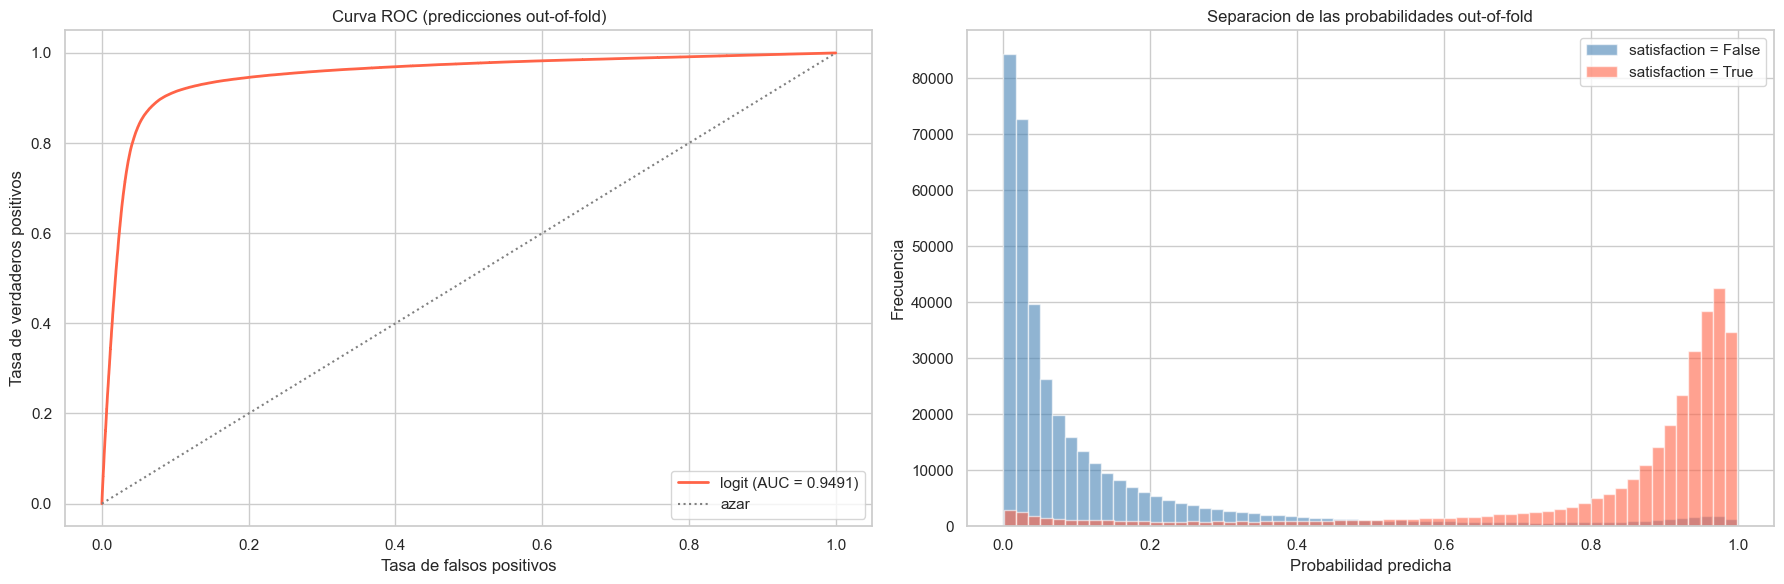

In [7]:
auc_oof = roc_auc_score(y, oof)
print(f"AUC out-of-fold: {auc_oof:.5f}   (media de CV: {cv_mean:.5f})")

fpr, tpr, _ = roc_curve(y, oof)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].plot(fpr, tpr, color="tomato", lw=2, label=f"logit (AUC = {auc_oof:.4f})")
axes[0].plot([0, 1], [0, 1], color="gray", ls=":", lw=1.5, label="azar")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Tasa de verdaderos positivos")
axes[0].set_title("Curva ROC (predicciones out-of-fold)")
axes[0].legend(loc="lower right")
for cls, color, etiqueta in [(0, "steelblue", "False"), (1, "tomato", "True")]:
    axes[1].hist(oof[y == cls], bins=60, alpha=0.6, color=color,
                 label=f"satisfaction = {etiqueta}")
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_ylabel("Frecuencia")
axes[1].set_title("Separacion de las probabilidades out-of-fold")
axes[1].legend()
plt.tight_layout()
plt.show()

In [8]:
# Donde se equivoca: AUC out-of-fold dentro de cada segmento grande
seg = pd.DataFrame({"y": y, "p": oof, "travel": train["Type of Travel"], "clase": train["Class"]})
print(seg.groupby(["travel", "clase"]).apply(
    lambda g: pd.Series({"n": len(g), "tasa": g["y"].mean(),
                         "auc": roc_auc_score(g["y"], g["p"]) if g["y"].nunique() > 1 else np.nan})
).round(4).to_string())

                                 n    tasa     auc
travel          clase                             
Business travel Business  338272.0  0.7325  0.9188
                Eco       141612.0  0.2600  0.9175
                Eco Plus   17557.0  0.3464  0.9187
Personal Travel Business    3940.0  0.1119  0.7882
                Eco       185792.0  0.0971  0.8050
                Eco Plus   12462.0  0.0954  0.8008


## 6. Modelo Final — Entrenamiento sobre todo el Train

In [9]:
modelo_final = logit(MEJOR_C).fit(X_train, y)
print(f"Modelo final entrenado sobre {X_train.shape[0]:,} filas y {X_train.shape[1]} columnas "
      f"({MEJOR}, C={MEJOR_C}).")

Modelo final entrenado sobre 699,635 filas y 123 columnas (E. D + cruces de viaje, C=0.1).


## 7. Coeficientes del Modelo

Las numéricas están estandarizadas, así que su coeficiente es el cambio en log-odds ante **un desvío
estándar**. Los de las categóricas se leen contra el nivel de referencia que descarta el one-hot.

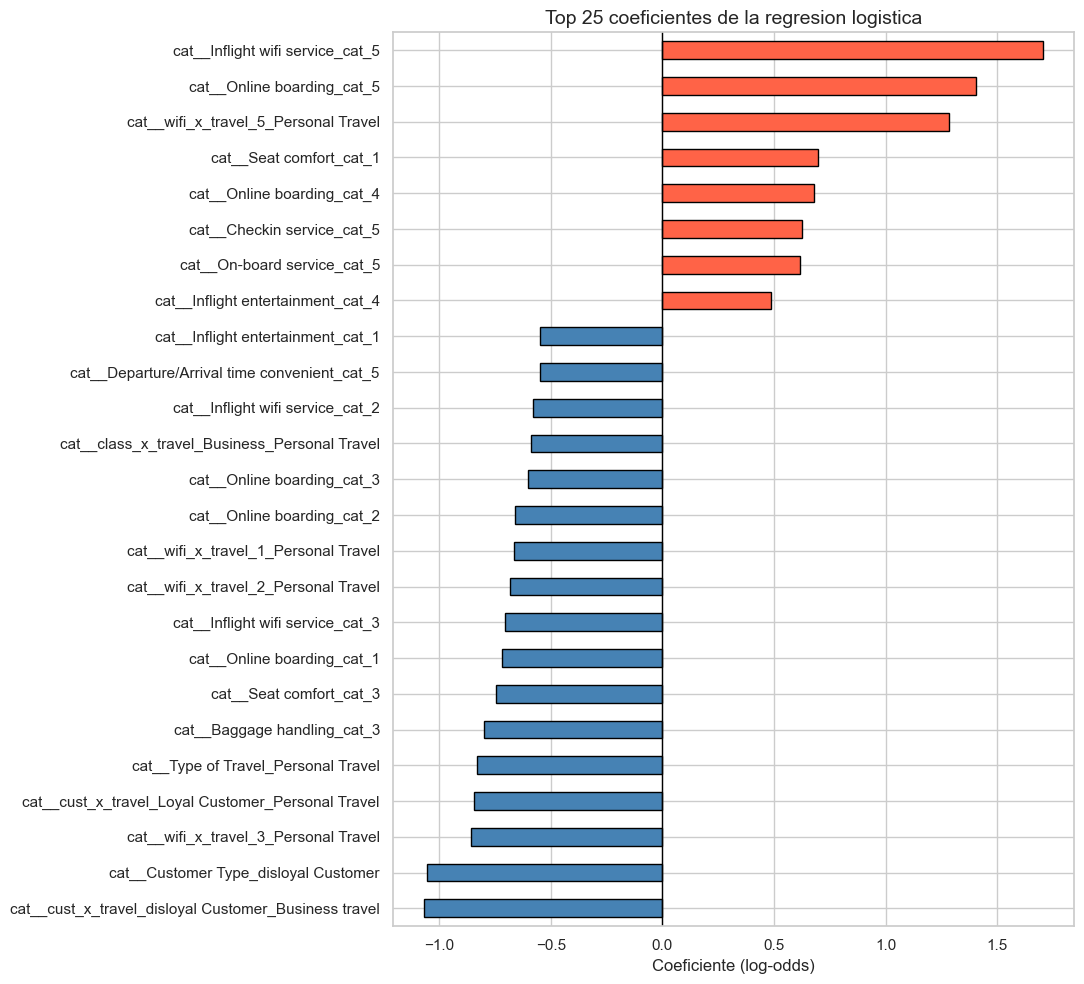

Top 15 por magnitud:
cat__Inflight wifi service_cat_5                        1.7056
cat__Online boarding_cat_5                              1.4057
cat__wifi_x_travel_5_Personal Travel                    1.2837
cat__cust_x_travel_disloyal Customer_Business travel   -1.0686
cat__Customer Type_disloyal Customer                   -1.0549
cat__wifi_x_travel_3_Personal Travel                   -0.8596
cat__cust_x_travel_Loyal Customer_Personal Travel      -0.8457
cat__Type of Travel_Personal Travel                    -0.8320
cat__Baggage handling_cat_3                            -0.8009
cat__Seat comfort_cat_3                                -0.7443
cat__Online boarding_cat_1                             -0.7186
cat__Inflight wifi service_cat_3                       -0.7043
cat__Seat comfort_cat_1                                 0.6958
cat__wifi_x_travel_2_Personal Travel                   -0.6843
cat__Online boarding_cat_4                              0.6782


In [10]:
nombres = pre.get_feature_names_out()
coefs   = pd.Series(modelo_final.coef_[0], index=nombres)
top     = coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(25).sort_values()

fig, ax = plt.subplots(figsize=(11, 10))
top.plot.barh(ax=ax, color=["steelblue" if v < 0 else "tomato" for v in top], edgecolor="black")
ax.axvline(0, color="black", lw=1)
ax.set_xlabel("Coeficiente (log-odds)")
ax.set_title("Top 25 coeficientes de la regresion logistica", fontsize=14)
plt.tight_layout()
plt.show()

print("Top 15 por magnitud:")
print(coefs.reindex(coefs.abs().sort_values(ascending=False).index).head(15).round(4).to_string())

## 8. Predicción sobre Test y Submission

In [11]:
proba_test = modelo_final.predict_proba(X_test)[:, 1]

# Se guardan OOF y test para poder stackear este modelo mas adelante
np.save("../models/2_logit_oof.npy", oof)
np.save("../models/2_logit_test.npy", proba_test)

submission = pd.DataFrame({"id": test["id"], TARGET: proba_test})
submission.to_csv("../submissions/2_logit_submission.csv", index=False)

print(f"Submission escrita: ../submissions/2_logit_submission.csv ({len(submission):,} filas)")
print(submission.head().to_string(index=False))
print(f"\nProbabilidad media predicha: {proba_test.mean():.4f}"
      f"  (tasa base en train: {y.mean():.4f})")

Submission escrita: ../submissions/2_logit_submission.csv (299,844 filas)
    id  satisfaction
699635      0.136738
699636      0.861389
699637      0.648418
699638      0.038255
699639      0.011015

Probabilidad media predicha: 0.4440  (tasa base en train: 0.4436)


In [12]:
# Chequeo de sanidad contra sample_submission (formato e ids)
sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "los ids no estan alineados"
assert submission[TARGET].between(0, 1).all(), "hay probabilidades fuera de [0, 1]"
assert submission[TARGET].notna().all(), "hay nulos en la prediccion"
print("Chequeos OK - submission lista para enviar.")

Chequeos OK - submission lista para enviar.


## 9. Envío a Kaggle vía API

In [13]:
COMPETITION = "playground-series-s6e10"
FILE        = "../submissions/2_logit_submission.csv"
MSG         = f"Logit - {MEJOR} - C={MEJOR_C} - CV AUC={cv_mean:.5f}"

!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

9 submissions remaining today.


  0%|          | 0.00/7.90M [00:00<?, ?B/s]
  0%|          | 16.0k/7.90M [00:00<01:00, 136kB/s]
  7%|▋         | 544k/7.90M [00:00<00:08, 870kB/s] 
  8%|▊         | 624k/7.90M [00:00<00:09, 790kB/s]
 11%|█▏        | 912k/7.90M [00:01<00:07, 1.02MB/s]
 30%|██▉       | 2.36M/7.90M [00:01<00:01, 3.74MB/s]
100%|██████████| 7.90M/7.90M [00:02<00:00, 4.09MB/s]



Successfully submitted to Predicting Airline Satisfaction


## 10. Conclusiones

_(se completan después de ejecutar)_